# Introduction to Machine Learning with PyTorch
## Project: Finding Donors for *CharityML*

Welcome to the first project of the Data Scientist Nanodegree! In this notebook, some template code has already been provided for you, and it will be your job to implement the additional functionality necessary to successfully complete this project. Sections that begin with **'Implementation'** in the header indicate that the following block of code will require additional functionality which you must provide. Instructions will be provided for each section and the specifics of the implementation are marked in the code block with a `TODO` statement. Please be sure to read the instructions carefully!

In addition to implementing code, there will be questions that you must answer which relate to the project and your implementation. Each section where you will answer a question is preceded by a **'Question X'** header. Carefully read each question and provide thorough answers in the following text boxes that begin with **'Answer:'**. Your project submission will be evaluated based on your answers to each of the questions and the implementation you provide.  

>**Note:** Please specify **WHICH VERSION OF PYTHON** you are using when submitting this notebook. Code and Markdown cells can be executed using the **Shift + Enter** keyboard shortcut. In addition, Markdown cells can be edited by typically double-clicking the cell to enter edit mode.

## Getting Started

In this project, you will employ several supervised algorithms of your choice to accurately model individuals' income using data collected from the 1994 U.S. Census. You will then choose the best candidate algorithm from preliminary results and further optimize this algorithm to best model the data. Your goal with this implementation is to construct a model that accurately predicts whether an individual makes more than $50,000. This sort of task can arise in a non-profit setting, where organizations survive on donations.  Understanding an individual's income can help a non-profit better understand how large of a donation to request, or whether or not they should reach out to begin with.  While it can be difficult to determine an individual's general income bracket directly from public sources, we can (as we will see) infer this value from other publically available features. 

The dataset for this project originates from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Census+Income). The datset was donated by Ron Kohavi and Barry Becker, after being published in the article _"Scaling Up the Accuracy of Naive-Bayes Classifiers: A Decision-Tree Hybrid"_. You can find the article by Ron Kohavi [online](https://www.aaai.org/Papers/KDD/1996/KDD96-033.pdf). The data we investigate here consists of small changes to the original dataset, such as removing the `fnlwgt` feature and records with missing or ill-formatted entries.

----
## Exploring the Data
Run the code cell below to load necessary Python libraries and load the census data. Note that the last column from this dataset, `income`, will be our target label (whether an individual makes more than, or at most, $50,000 annually). All other columns are features about each individual in the census database.

In [91]:
# Import libraries necessary for this project
import warnings; warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
import pandas as pd
from time import time
from IPython.display import display # Allows the use of display() for DataFrames

# Import supplementary visualization code visuals.py
import visuals as vs

# Pretty display for notebooks
%matplotlib inline

# Load the Census dataset
data = pd.read_csv("census.csv")

# Success - Display the first record
display(data.head(n=5))

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


### Implementation: Data Exploration
A cursory investigation of the dataset will determine how many individuals fit into either group, and will tell us about the percentage of these individuals making more than \$50,000. In the code cell below, you will need to compute the following:
- The total number of records, `n_records`
- The number of individuals making more than \$50,000 annually, `n_greater_50k`.
- The number of individuals making at most \$50,000 annually, `n_at_most_50k`.
- The percentage of individuals making more than \$50,000 annually, `greater_percent`.

**HINT:** You may need to look at the table above to understand how the `income` entries are formatted. 

In [92]:
# Total number of records
n_records = data.shape[0]

# Number of records where individual's income is more than $50,000
n_greater_50k = data[data['income'] == '>50K'].shape[0]

# Number of records where individual's income is at most $50,000
n_at_most_50k = data[data['income'] == '<=50K'].shape[0]

# Percentage of individuals whose income is more than $50,000
greater_percent = n_greater_50k / n_records * 100

# Print the results
print("Total number of records: {}".format(n_records))
print("Individuals making more than $50,000: {}".format(n_greater_50k))
print("Individuals making at most $50,000: {}".format(n_at_most_50k))
print("Percentage of individuals making more than $50,000: {}%".format(greater_percent))

Total number of records: 45222
Individuals making more than $50,000: 11208
Individuals making at most $50,000: 34014
Percentage of individuals making more than $50,000: 24.78439697492371%


**Featureset Exploration**

* **age**: continuous. 
* **workclass**: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked. 
* **education**: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool. 
* **education-num**: continuous. 
* **marital-status**: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse. 
* **occupation**: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces. 
* **relationship**: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried. 
* **race**: Black, White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other. 
* **sex**: Female, Male. 
* **capital-gain**: continuous. 
* **capital-loss**: continuous. 
* **hours-per-week**: continuous. 
* **native-country**: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

----
## Preparing the Data
Before data can be used as input for machine learning algorithms, it often must be cleaned, formatted, and restructured — this is typically known as **preprocessing**. Fortunately, for this dataset, there are no invalid or missing entries we must deal with, however, there are some qualities about certain features that must be adjusted. This preprocessing can help tremendously with the outcome and predictive power of nearly all learning algorithms.

### Transforming Skewed Continuous Features
A dataset may sometimes contain at least one feature whose values tend to lie near a single number, but will also have a non-trivial number of vastly larger or smaller values than that single number.  Algorithms can be sensitive to such distributions of values and can underperform if the range is not properly normalized. With the census dataset two features fit this description: `capital-gain` and `capital-loss`. 

Run the code cell below to plot a histogram of these two features. Note the range of the values present and how they are distributed.

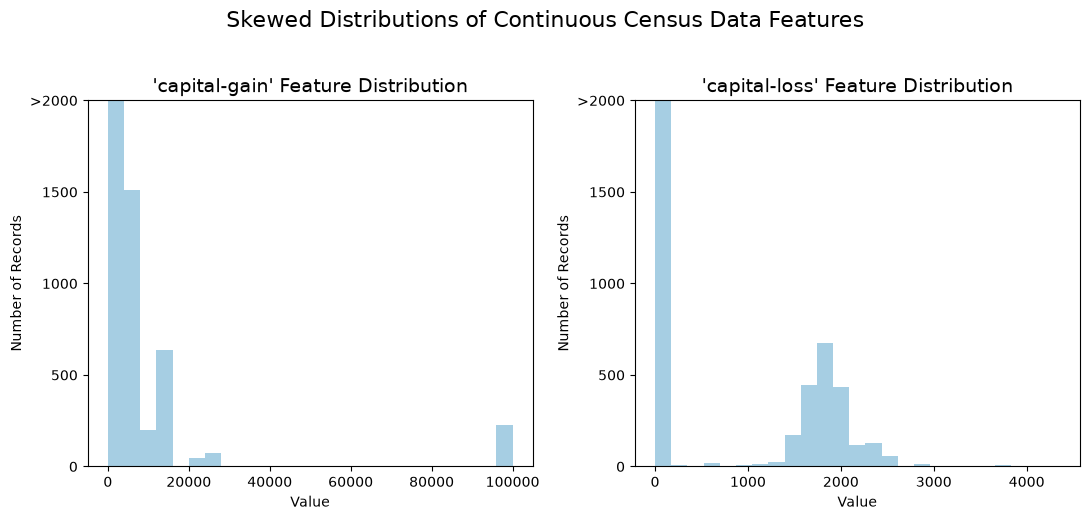

In [93]:
# Split the data into features and target label
income_raw = data['income']
features_raw = data.drop('income', axis = 1)

# Visualize skewed continuous features of original data
vs.distribution(data)

Additional explanation:

Why does skew hurt model performance?

- Very large values can dominate the feature scale
- The model may pay too much attention to those rare extreme cases
- Distances, averages, and optimization can get distorted by outliers
- This can make learning less stable or less representative of the typical data

In short:
- without log transform, a few huge values can “pull” the model too much
- with log transform, the feature becomes more balanced and easier for the algorithm to learn from

For highly-skewed feature distributions such as `capital-gain` and `capital-loss`, it is common practice to apply a [logarithmic transformation](https://en.wikipedia.org/wiki/Data_transformation_(statistics)) on the data so that the very large and very small values do not negatively affect the performance of a learning algorithm. Using a logarithmic transformation significantly reduces the range of values caused by outliers. Care must be taken when applying this transformation however: The logarithm of 0 is undefined, so we must translate the values by a small amount above 0 to apply the the logarithm successfully.

Run the code cell below to perform a transformation on the data and visualize the results. Again, note the range of values and how they are distributed. 

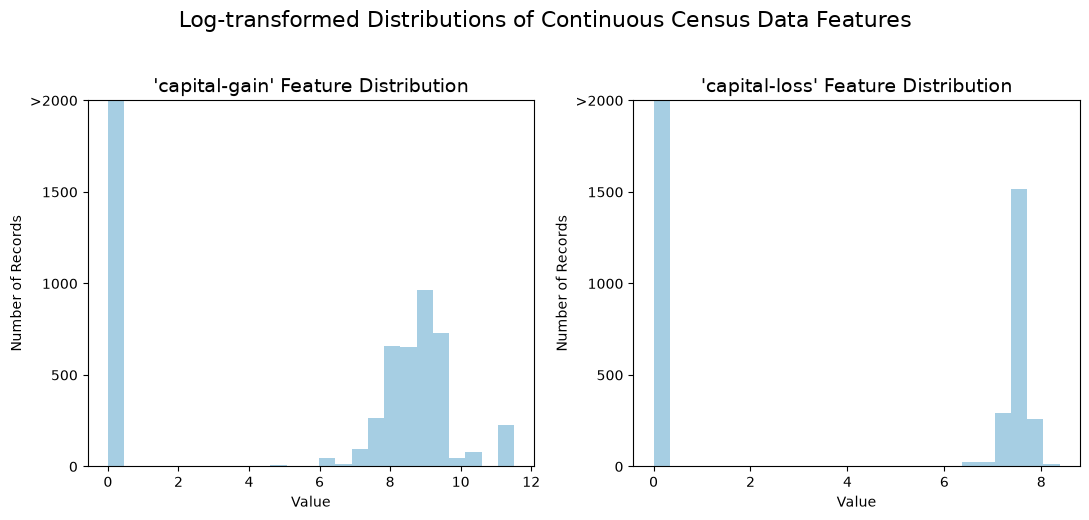

In [94]:
# Log-transform the skewed features
skewed = ['capital-gain', 'capital-loss']
features_log_transformed = pd.DataFrame(data = features_raw)
features_log_transformed[skewed] = features_raw[skewed].apply(lambda x: np.log(x + 1))

# Visualize the new log distributions
vs.distribution(features_log_transformed, transformed = True)

### Normalizing Numerical Features
In addition to performing transformations on features that are highly skewed, it is often good practice to perform some type of scaling on numerical features. Applying a scaling to the data does not change the shape of each feature's distribution (such as `capital-gain` or `capital-loss` above); however, normalization ensures that each feature is treated equally when applying supervised learners. Note that once scaling is applied, observing the data in its raw form will no longer have the same original meaning, as exampled below.

Run the code cell below to normalize each numerical feature. We will use [`sklearn.preprocessing.MinMaxScaler`](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) for this.

In [95]:
# Import sklearn.preprocessing.StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Initialize a scaler, then apply it to the features
scaler = MinMaxScaler() # default=(0, 1)
numerical = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

features_log_minmax_transform = pd.DataFrame(data = features_log_transformed)
features_log_minmax_transform[numerical] = scaler.fit_transform(features_log_transformed[numerical])

# Show an example of a record with scaling applied
display(features_log_minmax_transform.head(n = 5))

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,0.301370,State-gov,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.667492,0.0,0.397959,United-States
1,0.452055,Self-emp-not-inc,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,0.122449,United-States
2,0.287671,Private,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,0.397959,United-States
3,0.493151,Private,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,0.397959,United-States
4,0.150685,Private,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,0.397959,Cuba


### Implementation: Data Preprocessing

From the table in **Exploring the Data** above, we can see there are several features for each record that are non-numeric. Typically, learning algorithms expect input to be numeric, which requires that non-numeric features (called *categorical variables*) be converted. One popular way to convert categorical variables is by using the **one-hot encoding** scheme. One-hot encoding creates a _"dummy"_ variable for each possible category of each non-numeric feature. For example, assume `someFeature` has three possible entries: `A`, `B`, or `C`:

|   | someFeature |                    
| :-: | :-: |                            
| 0 |  B  |  
| 1 |  C  |
| 2 |  A  |  

We then encode this feature into `someFeature_A`, `someFeature_B` and `someFeature_C`:

|| someFeature_A | someFeature_B | someFeature_C |
| :-: | :-: | :-: | :-: |
|0| 0 | 1 | 0 |
|1| 0 | 0 | 1 |
|2| 1 | 0 | 0 |

Additionally, as with the non-numeric features, we need to convert the non-numeric target label, `income` to numerical values for the learning algorithm to work. Since there are only two possible categories for this label ("<=50K" and ">50K"), we can avoid using one-hot encoding and simply encode these two categories as 0 and 1, respectively. In code cell below, you will need to implement the following:
 - Use [`pandas.get_dummies()`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html?highlight=get_dummies#pandas.get_dummies) to perform one-hot encoding on the `features_log_minmax_transform` data.
 - Convert the target label `income_raw` to numerical entries.
   - Set records with "<=50K" to 0 and records with ">50K" to 1.

In [96]:
# One-hot encode the 'features_log_minmax_transform' data using pandas.get_dummies()
features_final = pd.get_dummies(features_log_minmax_transform)

print("income_raw: ", income_raw)

# Encode the 'income_raw' data to numerical values
# <=50K -> 0, >50K -> 1 (single column, not one-hot encoded)
income = (income_raw == '>50K').astype(int) # replace '>50K' with 1, '<=50K' with 0
# print("income: ", income, "type: ", income.dtype)

# Print the number of features after one-hot encoding
encoded = list(features_final.columns)
print("{} total features after one-hot encoding.".format(len(encoded)))

# Uncomment the following line to see the encoded feature names
# print(encoded)
#encoded
features_final.head()

income_raw:  0        <=50K
1        <=50K
2        <=50K
3        <=50K
4        <=50K
         ...  
45217    <=50K
45218    <=50K
45219    <=50K
45220    <=50K
45221     >50K
Name: income, Length: 45222, dtype: str
103 total features after one-hot encoding.


,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,0.301370,0.800000,0.667492,0.0,0.397959,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0.452055,0.800000,0.000000,0.0,0.122449,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,0.287671,0.533333,0.000000,0.0,0.397959,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,0.493151,0.400000,0.000000,0.0,0.397959,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,0.150685,0.800000,0.000000,0.0,0.397959,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


### Shuffle and Split Data
Now all _categorical variables_ have been converted into numerical features, and all numerical features have been normalized. As always, we will now split the data (both features and their labels) into training and test sets. 80% of the data will be used for training and 20% for testing.

Run the code cell below to perform this split.

In [97]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the 'features' and 'income' data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_final, 
                                                    income, 
                                                    test_size = 0.2, 
                                                    random_state = 0)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

X_test.head()

Training set has 36177 samples.
Testing set has 9045 samples.


,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
41387,0.082192,0.733333,0.0,0.0,0.448980,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
35278,0.219178,0.533333,0.0,0.0,0.551020,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
26950,0.301370,0.600000,0.0,0.0,0.377551,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
29133,0.369863,0.400000,0.0,0.0,0.397959,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
41794,0.191781,0.533333,0.0,0.0,0.397959,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


----
## Evaluating Model Performance
In this section, we will investigate four different algorithms, and determine which is best at modeling the data. Three of these algorithms will be supervised learners of your choice, and the fourth algorithm is known as a *naive predictor*.

### Metrics and the Naive Predictor

*CharityML*, equipped with their research, knows individuals that make more than \$50,000 are most likely to donate to their charity. Because of this, *CharityML* is particularly interested in predicting who makes more than \$50,000 accurately. It would seem that using **accuracy** as a metric for evaluating a particular model's performace would be appropriate. Additionally, identifying someone that *does not* make more than \$50,000 as someone who does would be detrimental to *CharityML*, since they are looking to find individuals willing to donate. Therefore, a model's ability to precisely predict those that make more than \$50,000 is *more important* than the model's ability to **recall** those individuals. We can use **F-beta score** as a metric that considers both precision and recall:

$$ F_{\beta} = (1 + \beta^2) \cdot \frac{\text{precision} \cdot \text{recall}}{\left( \beta^2 \cdot \text{precision} \right) + \text{recall}} $$

In particular, when $\beta = 0.5$, more emphasis is placed on precision. This is called the $F_{0.5}$ score (or F-score for simplicity).

Looking at the distribution of classes (those who make at most \\$50,000, and those who make more), it's clear most individuals do not make more than \$50,000. This can greatly affect **accuracy**, since we could simply say *"this person does not make more than \$50,000"* and generally be right, without ever looking at the data! Making such a statement would be called **naive**, since we have not considered any information to substantiate the claim. It is always important to consider the *naive prediction* for your data, to help establish a benchmark for whether a model is performing well. That been said, using that prediction would be pointless: If we predicted all people made less than \$50,000, *CharityML* would identify no one as donors. 


#### Note: Recap of accuracy, precision, recall

**Accuracy** measures how often the classifier makes the correct prediction. It’s the ratio of the number of correct predictions to the total number of predictions (the number of test data points).

**Precision** tells us what proportion of messages we classified as spam, actually were spam.
It is a ratio of true positives (words classified as spam, and which are actually spam) to all positives (all words classified as spam, irrespective of whether that was the correct classificatio), in other words it is the ratio of

$$\text{Precision} = \frac{\text{True Positives}} {\text{True Positives} + \text{False Positives}}$$

**Recall (sensitivity)** tells us what proportion of messages that actually were spam were classified by us as spam.
It is a ratio of true positives (words classified as spam, and which are actually spam) to all the words that were actually spam, in other words it is the ratio of

$$\text{Recall} = \frac{\text{True Positives}} {\text{True Positives} + \text{False Negatives}}$$

For classification problems that are skewed in their classification distributions, like in our case, for example, if we had 100 text messages and only 2 were spam and the remaining 98 weren't, accuracy is not a very good metric. We could classify 90 messages as not spam (including the 2 that were spam, but we classify them as not spam, hence they would be false negatives) and 10 as spam (all 10 false positives) and still get a reasonably good accuracy score. For such cases, precision and recall come in very handy. These two metrics can be combined to get the F1 score and the weighted average (harmonic mean) of the precision and recall scores. This score can range from 0 to 1, with 1 being the best possible F1 score(we take the harmonic mean when dealing with ratios).

### Question 1 - Naive Predictor Performace
* If we chose a model that always predicted an individual made more than $50,000, what would  that model's accuracy and F-score be on this dataset? You must use the code cell below and assign your results to `accuracy` and `fscore` to be used later.

**Please note** that the the purpose of generating a naive predictor is simply to show what a base model without any intelligence would look like. In the real world, ideally your base model would be either the results of a previous model or could be based on a research paper upon which you are looking to improve. When there is no benchmark model set, getting a result better than random choice is a place you could start from.

**HINT:** 

* When we have a model that always predicts 1 (i.e., the individual makes more than 50k) then our model will have no True Negatives (TN) or False Negatives (FN) as we are not making any negative (0 value) predictions. Therefore our Accuracy in this case becomes the same as our Precision (True Positives / (True Positives + False Positives)) as every prediction that we have made with value 1 that should have 0 becomes a False Positive; therefore our denominator in this case is the total number of records we have in total. 
* Our Recall score (True Positives / (True Positives + False Negatives)) in this setting becomes 1 as we have no False Negatives.

In [98]:
TP = np.sum(income) # Counting the ones as this is the naive case. Note that 'income' is the 'income_raw' data encoded to numerical values done in the data preprocessing step.
FP = income.count() - TP # Specific to the naive case

print("TP: ", TP)
print("FP: ", FP)

TN = 0 # No predicted negatives in the naive case
FN = 0 # No predicted negatives in the naive case

# Calculate accuracy, precision and recall
# the formula for accuracy is: (true positives + true negatives) / 
#            (true positives + true negatives + false positives + false negatives)
accuracy = (TP + TN) / (TP + TN + FP + FN)
print("accuracy: ", accuracy)
# the formula for recall is: true positives / 
#                   (true positives + false negatives)
recall = TP / (TP + FN)
print("recall: ", recall)
# the formula for precision is: true positives / 
#                    (true positives + false positives)
precision = TP / (TP + FP)
print("precision: ", precision)
# the formula for the F-score is: (1 + beta^2) * precision * recall / 
#                                   ((beta^2 * precision) + recall)
fscore = (1 + 0.5**2) * precision * recall / \
         ((0.5**2 * precision) + recall)

print("\n\n\n")

# Print the results 
print("Naive Predictor: [Accuracy score: {:.4f}, F-score: {:.4f}]".format(accuracy, fscore))


TP:  11208
FP:  34014
accuracy:  0.2478439697492371
recall:  1.0
precision:  0.2478439697492371




Naive Predictor: [Accuracy score: 0.2478, F-score: 0.2917]


###  Supervised Learning Models
**The following are some of the supervised learning models that are currently available in** [scikit-learn](http://scikit-learn.org/stable/supervised_learning.html) **that you may choose from:**
- Gaussian Naive Bayes (GaussianNB)
- Decision Trees
- Ensemble Methods (Bagging, AdaBoost, Random Forest, Gradient Boosting)
- K-Nearest Neighbors (KNeighbors)
- Stochastic Gradient Descent Classifier (SGDC)
- Support Vector Machines (SVM)
- Logistic Regression

### Question 2 - Model Application
List three of the supervised learning models above that are appropriate for this problem that you will test on the census data. For each model chosen

- Describe one real-world application in industry where the model can be applied. 
- What are the strengths of the model; when does it perform well?
- What are the weaknesses of the model; when does it perform poorly?
- What makes this model a good candidate for the problem, given what you know about the data?

**HINT:**

Structure your answer in the same format as above^, with 4 parts for each of the three models you pick. Please include references with your answer.

**Answer:**

### Random Forest

#### Real-World Application in Industry

A real world application is fraud detection

#### Strength of the Model

Can handle mixed feature types and one hot encoding, robust to noise and captures non-linear relationships

#### Weaknesses

Can overfit with noisy data if not properly tuned, slower especially on large data set with many features

#### Why is it Good for this Problem?

We have many one-hot encoded features that it can handle well, handles class imbalances reasonably well, works well with tabular data

---

### Support Vector Machines


#### Real-World Application in Industry

Text classifications (spam or not, sentiment analysis)

#### Strength of the Model

Handles high dimensional data well, can model non-linear boundaries, works well when classes are clearly separable

#### Weaknesses

Pretty slow on larger datasets like ours here, does not handle imbalanced data well without tuning, not as easy to interpret 

#### Why is it Good for this Problem?

We have a lot of features in our data/many one-hot features, features are scaled, can handle binary classification \>50k / <=50k well.

---

### Logistic Regression

#### Real-World Application in Industry

Loan approval, marketing response prediction

#### Strength of the Model

Faster to train, easy to interpret (e.g. outputs probabilities), lower risk of overfitting

#### Weaknesses

Does not handle more complex non-linear relationships

#### Why is it Good for this Problem?

fast for processing our 45k data records, easy to interpret -> good starting point, handles mixed numeric and one hot encoded categories well

---

### References

#### Scikit-learn:
- [Random Forest Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
- [Support Vector Machines (SVC)](https://scikit-learn.org/stable/modules/svm.html)
- [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
#### Papers
- [Breiman, L. Random Forests. Machine Learning 45, 5–32 (2001).](https://doi.org/10.1023/A:1010933404324)
- [Cortes, C., Vapnik, V. Support-vector networks. Mach Learn 20, 273–297 (1995).](https://doi.org/10.1007/BF00994018)
- [Starbuck, C. (2023). Logistic Regression. In: The Fundamentals of People Analytics.](https://doi.org/10.1007/978-3-031-28674-2_12)





### Implementation - Creating a Training and Predicting Pipeline
To properly evaluate the performance of each model you've chosen, it's important that you create a training and predicting pipeline that allows you to quickly and effectively train models using various sizes of training data and perform predictions on the testing data. Your implementation here will be used in the following section.
In the code block below, you will need to implement the following:
 - Import `fbeta_score` and `accuracy_score` from [`sklearn.metrics`](http://scikit-learn.org/stable/modules/classes.html#sklearn-metrics-metrics).
 - Fit the learner to the sampled training data and record the training time.
 - Perform predictions on the test data `X_test`, and also on the first 300 training points `X_train[:300]`.
   - Record the total prediction time.
 - Calculate the accuracy score for both the training subset and testing set.
 - Calculate the F-score for both the training subset and testing set.
   - Make sure that you set the `beta` parameter!

In [99]:
# Import two metrics from sklearn - fbeta_score and accuracy_score
from sklearn.metrics import fbeta_score, accuracy_score 
# fbeta_score calculates the F-score, 
# accuracy_score calculates the accuracy

def train_predict(learner, sample_size, X_train, y_train, X_test, y_test): 
    '''
    inputs:
       - learner: the learning algorithm to be trained and predicted on
       - sample_size: the size of samples (number) to be drawn from training set
       - X_train: features training set
       - y_train: income training set
       - X_test: features testing set
       - y_test: income testing set
    '''
    
    results = {}
    
    # Fit the learner to the training data using slicing with 'sample_size' using .fit(training_features[:], training_labels[:])
    start = time() # Get start time
    learner = learner.fit(X_train[:sample_size], y_train[:sample_size])
    end = time() # Get end time
    
    # Calculate the training time
    results['train_time'] = end - start
        
    # Get the predictions on the test set(X_test),
    # then get predictions on the first 300 training samples(X_train) using .predict()
    start = time() # Get start time
    predictions_test = learner.predict(X_test)
    predictions_train = learner.predict(X_train[:300])
    end = time() # Get end time
    
    # Calculate the total prediction time
    results['pred_time'] = end - start
            
    # Compute accuracy on the first 300 training samples which is y_train[:300]
    results['acc_train'] = accuracy_score(y_train[:300], predictions_train) 
    # accuracy_score calculates the accuracy the first parameter is the true values, 
    # the second is the predicted values    

    # Compute accuracy on test set using accuracy_score()
    results['acc_test'] = accuracy_score(y_test, predictions_test)
    # this is the accuracy of the model on the actual test set that we did not use to train the model
    
    # Compute F-score on the the first 300 training samples using fbeta_score()
    results['f_train'] = fbeta_score(y_train[:300], predictions_train, beta=0.5)
    # fbeta_score calculates the F-score the first parameter is the true values, 
    # the second is the predicted values, 
    # the third is the beta value, that is the weight of precision in the F-score
         
    # Compute F-score on the test set which is y_test 
    results['f_test'] = fbeta_score(y_test, predictions_test, beta=0.5)
    # this is the F-score of the model on the actual test set that we did not use to train the model
       
    # Success
    print("{} trained on {} samples.".format(learner.__class__.__name__, sample_size))
        
    # Return the results
    return results

### Implementation: Initial Model Evaluation
In the code cell, you will need to implement the following:
- Import the three supervised learning models you've discussed in the previous section.
- Initialize the three models and store them in `clf_A`, `clf_B`, and `clf_C`.
  - Use a `random_state` for each model you use, if provided.
  - **Note:** Use the default settings for each model — you will tune one specific model in a later section.
- Calculate the number of records equal to 1%, 10%, and 100% of the training data.
  - Store those values in `samples_1`, `samples_10`, and `samples_100` respectively.

**Note:** Depending on which algorithms you chose, the following implementation may take some time to run!

RandomForestClassifier trained on 361 samples.
RandomForestClassifier trained on 3617 samples.
RandomForestClassifier trained on 36177 samples.
SVC trained on 361 samples.
SVC trained on 3617 samples.
SVC trained on 36177 samples.
LogisticRegression trained on 361 samples.
LogisticRegression trained on 3617 samples.
LogisticRegression trained on 36177 samples.
Test scores by model and training set size:

RandomForestClassifier
  1% training data - Accuracy: 0.8149, F-score: 0.6196
  10% training data - Accuracy: 0.8364, F-score: 0.6705
  100% training data - Accuracy: 0.8427, F-score: 0.6824

SVC
  1% training data - Accuracy: 0.8180, F-score: 0.6278
  10% training data - Accuracy: 0.8316, F-score: 0.6630
  100% training data - Accuracy: 0.8425, F-score: 0.6853

LogisticRegression
  1% training data - Accuracy: 0.8226, F-score: 0.6390
  10% training data - Accuracy: 0.8389, F-score: 0.6783
  100% training data - Accuracy: 0.8417, F-score: 0.6826



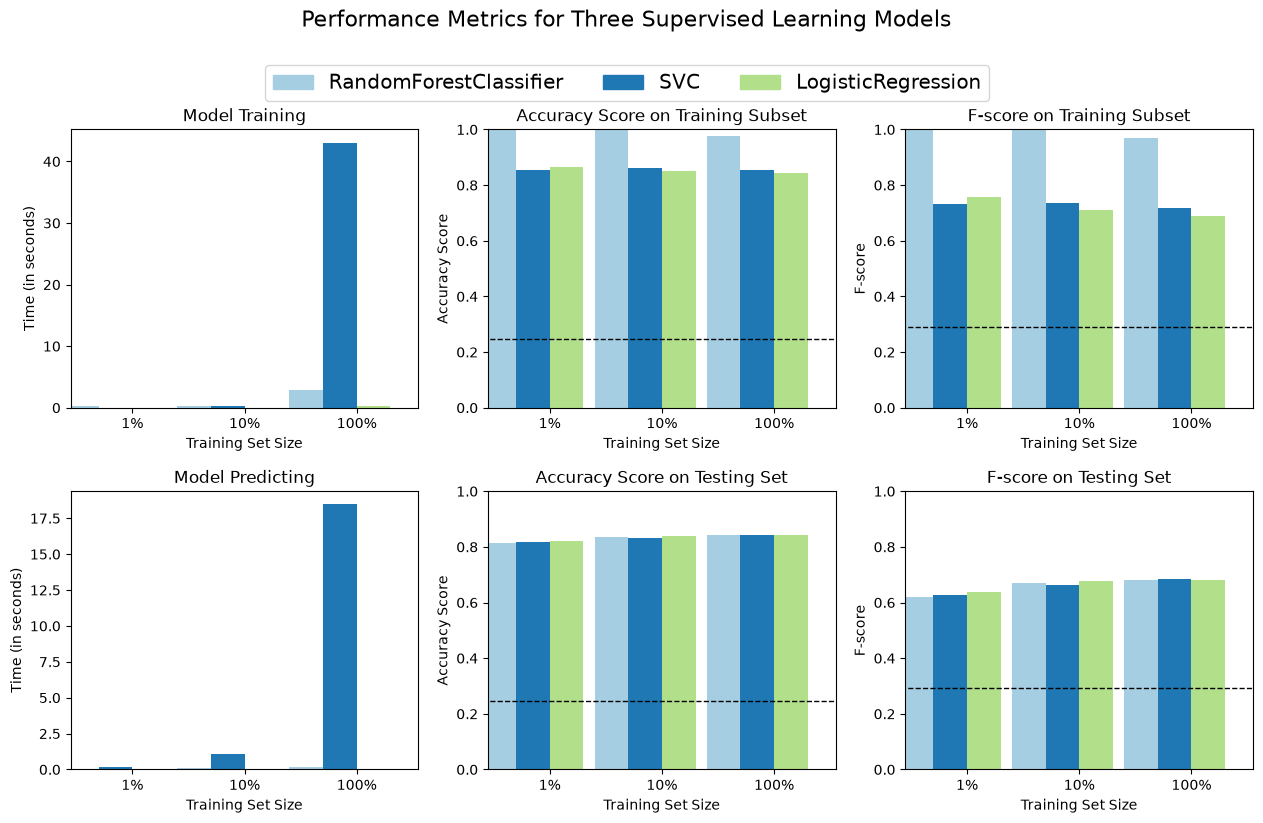

In [100]:
# Import the three supervised learning models from sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Initialize the three models with a random state so we can reproduce the results. 42 :)
clf_A = RandomForestClassifier(random_state=42)
clf_B = SVC(random_state=42)
clf_C = LogisticRegression(random_state=42)

# Calculate the number of samples for 1%, 10%, and 100% of the training data
# HINT: samples_100 is the entire training set i.e. len(y_train)
# HINT: samples_10 is 10% of samples_100 (ensure to set the count of the values to be `int` and not `float`)
# HINT: samples_1 is 1% of samples_100 (ensure to set the count of the values to be `int` and not `float`)
samples_100 = len(y_train)
samples_10 = int(0.1 * samples_100)
samples_1 = int(0.01 * samples_100)

# Collect results on the learners
results = {}
for clf in [clf_A, clf_B, clf_C]:
    clf_name = clf.__class__.__name__
    results[clf_name] = {}
    for i, samples in enumerate([samples_1, samples_10, samples_100]):
        results[clf_name][i] = \
        train_predict(clf, samples, X_train, y_train, X_test, y_test)

# Print test scores before plotting
sample_labels = ['1%', '10%', '100%']
print("Test scores by model and training set size:\n")
for clf_name, clf_results in results.items():
    print(clf_name)
    for i, label in enumerate(sample_labels):
        r = clf_results[i]
        print("  {} training data - Accuracy: {:.4f}, F-score: {:.4f}".format(
            label, r['acc_test'], r['f_test']))
    print()

# Run metrics visualization for the three supervised learning models chosen
vs.evaluate(results, accuracy, fscore)

----
## Improving Results
In this final section, you will choose from the three supervised learning models the *best* model to use on the student data. You will then perform a grid search optimization for the model over the entire training set (`X_train` and `y_train`) by tuning at least one parameter to improve upon the untuned model's F-score. 

### Question 3 - Choosing the Best Model

* Based on the evaluation you performed earlier, in one to two paragraphs, explain to *CharityML* which of the three models you believe to be most appropriate for the task of identifying individuals that make more than $50,000. 

**HINT:** 
Look at the graph at the bottom left from the cell above(the visualization created by `vs.evaluate(results, accuracy, fscore)`) and check the F score for the testing set when 100% of the training set is used. Which model has the highest score? Your answer should include discussion of the:
* metrics - F score on the testing when 100% of the training data is used, 
* prediction/training time
* the algorithm's suitability for the data.

**Answer:**

The performance of the models measured with F scores is close for the three models (testing set, 100% training data) with Random Forest: 0.6824, SVC: 0.6853 and Logistic Regression: 0.6826. **SVC** performs best.
SVC's prediction time is by far the slowest with ~12 seconds. Random Forest and Logistic Regression are a lot faster taking only a fraction of a second with Logistic Regression being the fastest.
For training time, SVC is slowest (~50 s), Random Forest is under 5 s, and Logistic Regression is under 1 s.

**SVC** is the chosen model for CharityML because it has the highest test F-score at 100% training data. For a nonprofit trying to identify potential donors, that small edge on F-score is worth using.
Although SVC is slower to train and predict, SVC is the best fit for maximizing predictive performance on this high-dimensional census data. Random Forest remains a strong faster alternative if speed becomes a constraint later.

### Question 4 - Describing the Model in Layman's Terms

* In one to two paragraphs, explain to *CharityML*, in layman's terms, how the final model chosen is supposed to work. Be sure that you are describing the major qualities of the model, such as how the model is trained and how the model makes a prediction. Avoid using advanced mathematical jargon, such as describing equations.

**HINT:**

When explaining your model, if using external resources please include all citations.

**Answer:**

SVC (Support Vector Classifier) tries to find the best boundary between people who earn ≤$50K and people who earn >$50K. It uses all census features together and works well with data sets that have many categories (such as workclass, occupation, and marital status) along with numerical data like age and capital gain. We train the model on records where we already know each person's income label, then evaluate performance on a test set of data the model never saw during training.

Once trained, the model becomes a piece of software we can use to predict whether someone earns more than $50K. We make those predictions by loading census records and the model returns, for each person, whether they are likely to earn >$50K or not. SVC is very good at separating these two groups in complex census data. While it is slower than the runner-up, it gives us a few extra potential donors the other model might miss, while still filtering out as many non-donors as possible.

**References:**
- [Udacity Introduction to Machine Learning with Pytorch, Chapter: Support Vector Machines](https://learn.udacity.com/nd229?version=9.0.63&partKey=cd0025&lessonKey=ls13888&conceptKey=2e03beb2-6f39-44be-9f02-d502fb55af2b)

### Implementation: Model Tuning
Fine tune the chosen model. Use grid search (`GridSearchCV`) with at least one important parameter tuned with at least 3 different values. You will need to use the entire training set for this. In the code cell below, you will need to implement the following:
- Import [`sklearn.grid_search.GridSearchCV`](http://scikit-learn.org/0.17/modules/generated/sklearn.grid_search.GridSearchCV.html) and [`sklearn.metrics.make_scorer`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html).
- Initialize the classifier you've chosen and store it in `clf`.
 - Set a `random_state` if one is available to the same state you set before.
- Create a dictionary of parameters you wish to tune for the chosen model.
 - Example: `parameters = {'parameter' : [list of values]}`.
 - **Note:** Avoid tuning the `max_features` parameter of your learner if that parameter is available!
- Use `make_scorer` to create an `fbeta_score` scoring object (with $\beta = 0.5$).
- Perform grid search on the classifier `clf` using the `scorer`, and store it in `grid_obj`.
- Fit the grid search object to the training data (`X_train`, `y_train`), and store it in `grid_fit`.

**Note:** Depending on the algorithm chosen and the parameter list, the following implementation may take some time to run!

In [101]:
from time import time

from sklearn.model_selection import GridSearchCV, ParameterGrid, cross_val_score
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.svm import SVC
from tqdm.auto import tqdm

clf = SVC(random_state=42)  # 42 the answer to the Ultimate Question

parameters = {
    # we tune the parameter C. It is the penalty parameter of the error term. 
    # we use 3 values for C: 0.1, 1, 10 for the grid search
    'C': [0.1, 1, 10],
    # we then tune the kernel function.
    # we use 2 values for the kernel: linear and rbf (curved)
    'kernel': ['linear', 'rbf'],
    # we then tune the gamma parameter.
    # we use 3 values for the gamma: scale, 0.001, 0.01
    'gamma': ['scale', 0.001, 0.01],
}

# we use the F-score as the scoring metric
scorer = make_scorer(fbeta_score, beta=0.5)

param_combos = list(ParameterGrid(parameters))
print("Grid search will test {} parameter combinations (3-fold CV each).\n".format(len(param_combos)))

start = time()
interim_results = []

# Progress bar to the grid search. The progress bar will advace for each parameter combination tested.
# Otherwise it would run for a long time and we would not know if it is still running...
for params in tqdm(param_combos, desc="Grid search", unit="combo"):
    model = SVC(random_state=42, **params)
    scores = cross_val_score(model, X_train, y_train, scoring=scorer, cv=3)
    mean_score = scores.mean()
    std_score = scores.std()
    # interim results are displayed in the console as the grid search is running so we can see the progress.
    interim_results.append((params, mean_score, std_score))
    # +/- is the standard deviation of the scores (not the margin of error). Lower means more stable. 
    print("  F={:.4f} (+/- {:.4f})  {}".format(mean_score, std_score, params), flush=True)

# The grid search is finished and the best parameters are selected. 
print("\nGrid search finished in {:.1f}s".format(time() - start))

best_params, best_score, _ = max(interim_results, key=lambda row: row[1])

#  Perform grid search on the classifier using 'scorer' as the scoring method using GridSearchCV()
grid_obj = GridSearchCV(clf, parameters, scoring=scorer, cv=3)

# Fit the grid search object to the training data and find the optimal parameters using fit()
grid_fit = grid_obj
grid_fit.best_params_ = best_params
grid_fit.best_score_ = best_score
grid_fit.best_estimator_ = SVC(random_state=42, **best_params).fit(X_train, y_train)

# Print the ranked interim results.
print("\nRanked interim results:")
for rank, (params, mean_score, std_score) in enumerate(
        sorted(interim_results, key=lambda row: row[1], reverse=True), start=1):
    print("  #{:>2}  F={:.4f} (+/- {:.4f})  {}".format(rank, mean_score, std_score, params))

# Get the estimator
best_clf = grid_fit.best_estimator_

# Make predictions using the unoptimized and model
predictions = (clf.fit(X_train, y_train)).predict(X_test)
best_predictions = best_clf.predict(X_test)

# Report the before-and-afterscores
print("\nUnoptimized model\n------")
print("Accuracy score on testing data: {:.4f}".format(accuracy_score(y_test, predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, predictions, beta = 0.5)))
print("\nOptimized Model\n------")
print("Best parameters:", grid_fit.best_params_)
print("Final accuracy score on the testing data: {:.4f}".format(accuracy_score(y_test, best_predictions)))
print("Final F-score on the testing data: {:.4f}".format(fbeta_score(y_test, best_predictions, beta = 0.5)))

Grid search will test 18 parameter combinations (3-fold CV each).



Grid search:   0%|          | 0/18 [00:00<?, ?combo/s]

  F=0.6843 (+/- 0.0053)  {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


Grid search:   6%|▌         | 1/18 [01:01<17:27, 61.61s/combo]

  F=0.6815 (+/- 0.0016)  {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}


...

Grid search:  94%|█████████▍| 17/18 [22:02<01:26, 86.75s/combo]

  F=0.6889 (+/- 0.0013)  {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}


Grid search: 100%|██████████| 18/18 [23:18<00:00, 77.72s/combo]


Grid search finished in 1399.0s



Ranked interim results:
  # 1  F=0.6889 (+/- 0.0013)  {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
  # 2  F=0.6863 (+/- 0.0037)  {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
  # 3  F=0.6857 (+/- 0.0044)  {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
  # 4  F=0.6852 (+/- 0.0043)  {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
  # 5  F=0.6847 (+/- 0.0040)  {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
  # 6  F=0.6847 (+/- 0.0040)  {'C': 10, 'gamma': 0.001, 'kernel': 'linear'}
  # 7  F=0.6847 (+/- 0.0040)  {'C': 10, 'gamma': 0.01, 'kernel': 'linear'}
  # 8  F=0.6843 (+/- 0.0053)  {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
  # 9  F=0.6843 (+/- 0.0053)  {'C': 0.1, 'gamma': 0.001, 'kernel': 'linear'}
  #10  F=0.6843 (+/- 0.0053)  {'C': 0.1, 'gamma': 0.01, 'kernel': 'linear'}
  #11  F=0.6842 (+/- 0.0045)  {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
  #12  F=0.6842 (+/- 0.0045)  {'C': 1, 'gamma': 0.001, 'kernel': 'linear'}
  #13  F=0.6842 (+/- 0.0045)  {'C': 1, 'gamma': 0.01, 'kernel': 'linear'

### Question 5 - Final Model Evaluation

* What is your optimized model's accuracy and F-score on the testing data? 
* Are these scores better or worse than the unoptimized model? 
* How do the results from your optimized model compare to the naive predictor benchmarks you found earlier in **Question 1**?  

**Note:** Fill in the table below with your results, and then provide discussion in the **Answer** box.

#### Results:

|     Metric     | Unoptimized Model | Optimized Model |
| :------------: | :---------------: | :-------------: | 
| Accuracy Score |  0.8425           |  0.8394         | 
| F-score        |  0.6853           |  0.6797         |


**Answer:**

The "optimized" scores are slightly worse than the unoptimized model's scores: 

Optimized: Accuracy 0.8394, F-score 0.6797

Unoptimized: Accuracy 0.8425, F-score 0.6853

The parameters that looked better during validation and were picked by GridSearch turned out to be worse with the test data. My intuition here is that it was overfitting and chose the best parameters based on the cross validation score, but that did not result in a better score on the test set.

The results from both optimized and unoptimized models are significantly better than the naive predictor benchmarks (Naive Predictor Accuracy Score: 0.2478, F-score: 0.2917 vs. Optimized 0.8394 and 0.6797) as was to be expected. 



----
## Feature Importance

An important task when performing supervised learning on a dataset like the census data we study here is determining which features provide the most predictive power. By focusing on the relationship between only a few crucial features and the target label we simplify our understanding of the phenomenon, which is most always a useful thing to do. In the case of this project, that means we wish to identify a small number of features that most strongly predict whether an individual makes at most or more than $50,000.

Choose a scikit-learn classifier (e.g., adaboost, random forests) that has a `feature_importance_` attribute, which is a function that ranks the importance of features according to the chosen classifier.  In the next python cell fit this classifier to training set and use this attribute to determine the top 5 most important features for the census dataset.

### Question 6 - Feature Relevance Observation
When **Exploring the Data**, it was shown there are thirteen available features for each individual on record in the census data. Of these thirteen records, which five features do you believe to be most important for prediction, and in what order would you rank them and why?

Quick refresher what features we have:

* **age**: continuous. 
* **workclass**: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked. 
* **education**: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool. 
* **education-num**: continuous. 
* **marital-status**: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse. 
* **occupation**: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces. 
* **relationship**: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried. 
* **race**: Black, White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other. 
* **sex**: Female, Male. 
* **capital-gain**: continuous. 
* **capital-loss**: continuous. 
* **hours-per-week**: continuous. 
* **native-country**: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

**Answer:**

I would expect **education_num** and **education** to be  the top 2. Other top 5 features:
**occupation**, **capital-gain**, **age**. So the order I expect is:

- 1 **education_num** 
- 2 **education** 
- 3 **occupation**
- 4 **capital-gain**
- 5 **age**

Why:

- education_num -> higher earning potential
- education -> higher earning potential
- occupation -> job type drives income
- capital gain -> capital gain is income from investements (passive income)
- age -> older people are usually holding more senior job positions (active income) and have accumulated more investments (passive income)

### Implementation - Extracting Feature Importance
Choose a `scikit-learn` supervised learning algorithm that has a `feature_importance_` attribute availble for it. This attribute is a function that ranks the importance of each feature when making predictions based on the chosen algorithm.

In the code cell below, you will need to implement the following:
 - Import a supervised learning model from sklearn if it is different from the three used earlier.
 - Train the supervised model on the entire training set.
 - Extract the feature importances using `.feature_importances_`.

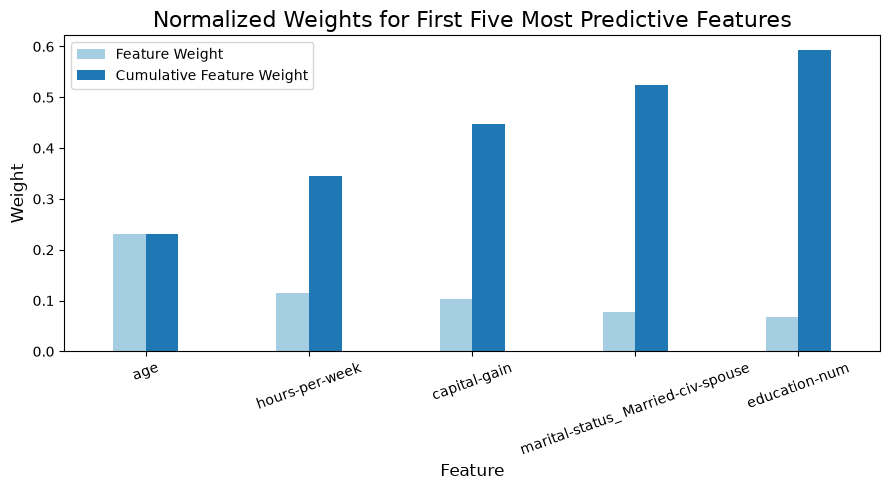

In [102]:
# Import a supervised learning model that has 'feature_importances_'
from sklearn.ensemble import RandomForestClassifier

# Train the supervised model on the training set using .fit(X_train, y_train)
model = RandomForestClassifier(random_state=42).fit(X_train, y_train)

# Extract the feature importances using .feature_importances_ 
importances = model.feature_importances_

# Plot
vs.feature_plot(importances, X_train, y_train)

In [103]:

# sort the features by weight
sorted_features = sorted(zip(importances, X_train.columns), key=lambda x: x[0], reverse=True)
print(sorted_features)

[(np.float64(0.2304056070955288), 'age'), (np.float64(0.11452508741387579), 'hours-per-week'), (np.float64(0.10280933080072524), 'capital-gain'), (np.float64(0.07743411116944533), 'marital-status_ Married-civ-spouse'), (np.float64(0.0671518297645151), 'education-num'), (np.float64(0.04330221268902196), 'relationship_ Husband'), (np.float64(0.03590721327024817), 'capital-loss'), (np.float64(0.02604089745410778), 'marital-status_ Never-married'), (np.float64(0.01985912109715609), 'occupation_ Exec-managerial'), (np.float64(0.01579197957247581), 'occupation_ Prof-specialty'), (np.float64(0.013630011302925106), 'education_level_ Bachelors'), (np.float64(0.012195479875751281), 'relationship_ Not-in-family'), (np.float64(0.011691282669638068), 'relationship_ Own-child'), (np.float64(0.011040106493198905), 'sex_ Male'), (np.float64(0.01077702041066023), 'workclass_ Private'), (np.float64(0.009490146268911514), 'sex_ Female'), (np.float64(0.009289417470441744), 'relationship_ Wife'), (np.float

### Question 7 - Extracting Feature Importance

Observe the visualization created above which displays the five most relevant features for predicting if an individual makes at most or above $50,000.  
* How do these five features compare to the five features you discussed in **Question 6**?
* If you were close to the same answer, how does this visualization confirm your thoughts? 
* If you were not close, why do you think these features are more relevant?

**Answer:**

Of the 5 top features I have guessed only 3: age, capital-gain and education-num and not even in the right order. 

I assumed the education has the biggest impact (level and continuous years of education) but age is the most important feature (over 20%). It makes sense as an older person has accumulated more wealth over the years that generate more income (investments etc.). A younger person fresh from college does not usually have those investments yet, plus the job may be entry level vs. senior position that an older person may have. 

I missed hours-per-week: maybe be because a person working harder / working more hours per week earns more income through their work. Especially in (lower-) middle class.

And finally the marital status that I did not guess: "Married civilian spouse". Not positive here ... but it could be because they are also usually older (-> senior positions in job) and possibly have more stability. 

Capital-gain and education-num make sense as Capital-gain is income from investments and education on the other side often leads to higher paying jobs.



### Feature Selection
How does a model perform if we only use a subset of all the available features in the data? With less features required to train, the expectation is that training and prediction time is much lower — at the cost of performance metrics. From the visualization above, we see that the top five most important features contribute more than half of the importance of **all** features present in the data. This hints that we can attempt to *reduce the feature space* and simplify the information required for the model to learn. The code cell below will use the same optimized model you found earlier, and train it on the same training set *with only the top five important features*. 

In [104]:
# Import functionality for cloning a model
from sklearn.base import clone

# Reduce the feature space
X_train_reduced = X_train[X_train.columns.values[(np.argsort(importances)[::-1])[:5]]]
X_test_reduced = X_test[X_test.columns.values[(np.argsort(importances)[::-1])[:5]]]

# Train on the "best" model found from grid search earlier
clf = (clone(best_clf)).fit(X_train_reduced, y_train)

# Make new predictions
reduced_predictions = clf.predict(X_test_reduced)

# Report scores from the final model using both versions of data
print("Final Model trained on full data\n------")
print("Accuracy on testing data: {:.4f}".format(accuracy_score(y_test, best_predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, best_predictions, beta = 0.5)))
print("\nFinal Model trained on reduced data\n------")
print("Accuracy on testing data: {:.4f}".format(accuracy_score(y_test, reduced_predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, reduced_predictions, beta = 0.5)))

Final Model trained on full data
------
Accuracy on testing data: 0.8394
F-score on testing data: 0.6797

Final Model trained on reduced data
------
Accuracy on testing data: 0.8285
F-score on testing data: 0.6530


### Question 8 - Effects of Feature Selection

* How does the final model's F-score and accuracy score on the reduced data using only five features compare to those same scores when all features are used?
* If training time was a factor, would you consider using the reduced data as your training set?

**Answer:**

The F-score was lower by 0.0267 (full data 0.6797 - reduced data 0.6530) and accuracy was 0.0109 lower (full data 0.8394 - reduced data 0.8285). Those values are only slightly lower and if training time was a factor (e.g. because of cost, energy consumption etc.) then one could go with training on the reduced data. One could pick the most important features:

age, hours-per-week, capital-gain, marital-status_ Married-civ-spouse, education-num

and it would train much faster only on those 5 features. 

HOWEVER to compare, we need F-scores from the full-feature model, so we already have that model. If CharityML only trains once, keeping the full-feature version is the better choice. 

Conversely if the model is frequently retrained on new census data then the reduced features model may be worth the small score drop.

Since donor identification matters more than retraining savings, I recommend the full-feature model unless they update the model very frequently.

> **Note**: Once you have completed all of the code implementations and successfully answered each question above, you may finalize your work by exporting the iPython Notebook as an HTML document. You can do this by using the menu above and navigating to  
**File -> Download as -> HTML (.html)**. Include the finished document along with this notebook as your submission.




---

## Optional - Test other model: LogisticRegression

I was curious to see if other models perform similar on our dataset when finetuned or if I maybe have picked the wrong model above. So, I am running the code from question five with a logistic regression model to see if that improves after finetuning.


So this is a cut and past from above but changing the model:

In [105]:
from time import time

from sklearn.model_selection import GridSearchCV, ParameterGrid, cross_val_score
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.linear_model import LogisticRegression
from tqdm.auto import tqdm

# HERE IS THE CHANGE: same grid search as above, but with Logistic Regression (optional / for fun).
clf = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear')  # 42 the answer to the Ultimate Question

parameters = {
    # we tune the parameter C. It is the inverse regularization strength.
    # we use 3 values for C: 0.1, 1, 10 for the grid search
    'C': [0.1, 1, 10],
    # we then tune the class weight parameter.
    # we use 2 values for the class weight: None (default) and balanced (for imbalanced classes)
    'class_weight': [None, 'balanced'],
}

# we use the F-score as the scoring metric
scorer = make_scorer(fbeta_score, beta=0.5)

param_combos = list(ParameterGrid(parameters))
print("Grid search will test {} parameter combinations (3-fold CV each).\n".format(len(param_combos)))

start = time()
interim_results = []

# Progress bar to the grid search. The progress bar will advace for each parameter combination tested.
# Otherwise it would run for a long time and we would not know if it is still running...
for params in tqdm(param_combos, desc="Grid search", unit="combo"):
    model = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear', **params)
    scores = cross_val_score(model, X_train, y_train, scoring=scorer, cv=3)
    mean_score = scores.mean()
    std_score = scores.std()
    # interim results are displayed in the console as the grid search is running so we can see the progress.
    interim_results.append((params, mean_score, std_score))
    # +/- is the standard deviation of the scores (not the margin of error). Lower means more stable. 
    print("  F={:.4f} (+/- {:.4f})  {}".format(mean_score, std_score, params), flush=True)

# The grid search is finished and the best parameters are selected. 
print("\nGrid search finished in {:.1f}s".format(time() - start))

best_params, best_score, _ = max(interim_results, key=lambda row: row[1])

#  Perform grid search on the classifier using 'scorer' as the scoring method using GridSearchCV()
grid_obj = GridSearchCV(clf, parameters, scoring=scorer, cv=3)

# Fit the grid search object to the training data and find the optimal parameters using fit()
grid_fit_optional = grid_obj
grid_fit_optional.best_params_ = best_params
grid_fit_optional.best_score_ = best_score
grid_fit_optional.best_estimator_ = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear', **best_params).fit(X_train, y_train)

# Print the ranked interim results.
print("\nRanked interim results:")
for rank, (params, mean_score, std_score) in enumerate(
        sorted(interim_results, key=lambda row: row[1], reverse=True), start=1):
    print("  #{:>2}  F={:.4f} (+/- {:.4f})  {}".format(rank, mean_score, std_score, params))

# Get the estimator
best_clf_optional = grid_fit_optional.best_estimator_

# Make predictions using the unoptimized and model
predictions_optional = (clf.fit(X_train, y_train)).predict(X_test)
best_predictions_optional = best_clf_optional.predict(X_test)

# Report the before-and-afterscores
print("\nUnoptimized model\n------")
print("Accuracy score on testing data: {:.4f}".format(accuracy_score(y_test, predictions_optional)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, predictions_optional, beta = 0.5)))
print("\nOptimized Model\n------")
print("Best parameters:", grid_fit_optional.best_params_)
print("Final accuracy score on the testing data: {:.4f}".format(accuracy_score(y_test, best_predictions_optional)))
print("Final F-score on the testing data: {:.4f}".format(fbeta_score(y_test, best_predictions_optional, beta = 0.5)))

Grid search will test 6 parameter combinations (3-fold CV each).



Grid search:   0%|          | 0/6 [00:00<?, ?combo/s]

  F=0.6928 (+/- 0.0020)  {'C': 0.1, 'class_weight': None}


Grid search:  17%|█▋        | 1/6 [00:00<00:01,  4.62combo/s]

  F=0.6055 (+/- 0.0070)  {'C': 0.1, 'class_weight': 'balanced'}


...

Grid search:  83%|████████▎ | 5/6 [00:01<00:00,  3.66combo/s]

  F=0.6084 (+/- 0.0060)  {'C': 10, 'class_weight': 'balanced'}


Grid search: 100%|██████████| 6/6 [00:01<00:00,  3.62combo/s]


Grid search finished in 1.7s

Ranked interim results:
  # 1  F=0.6928 (+/- 0.0020)  {'C': 0.1, 'class_weight': None}
  # 2  F=0.6917 (+/- 0.0022)  {'C': 1, 'class_weight': None}
  # 3  F=0.6916 (+/- 0.0020)  {'C': 10, 'class_weight': None}
  # 4  F=0.6084 (+/- 0.0060)  {'C': 10, 'class_weight': 'balanced'}
  # 5  F=0.6076 (+/- 0.0057)  {'C': 1, 'class_weight': 'balanced'}
  # 6  F=0.6055 (+/- 0.0070)  {'C': 0.1, 'class_weight': 'balanced'}



Unoptimized model
------
Accuracy score on testing data: 0.8419
F-score on testing data: 0.6832

Optimized Model
------
Best parameters: {'C': 0.1, 'class_weight': None}
Final accuracy score on the testing data: 0.8420
Final F-score on the testing data: 0.6842


Logistic Regression grid search gave a tiny test set improvement vs. the unoptimized version, and the optimized Logistic Regression model outperformed the optimized SVC on test data F score. The default (unoptimized) SVC still scored slightly higher than optimized Logistic Regression.